In [32]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [33]:
# =========================
# 1. DATASET PATH (FIXED)
# =========================
dataset_path = "/kaggle/input/plantdisease/PlantVillage"

print("Using dataset:", dataset_path)

Using dataset: /kaggle/input/plantdisease/PlantVillage


In [34]:
# =========================
# 2. DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
# =========================
# 3. TRANSFORMS
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# 4. LOAD DATASET
# =========================
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [36]:
# =========================
# 5. TRAIN / VAL SPLIT
# =========================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [37]:
# =========================
# 6. MODEL (RESNET18)
# =========================
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
# =========================
# 7. LOSS + OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [39]:
# =========================
# 8. METRICS
# =========================
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [40]:
# =========================
# 9. TRAINING LOOP
# =========================
epochs = 5

for epoch in range(epochs):

    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch [1/5]
Train Loss: 0.4838 | Train Acc: 0.8398
Val Loss: 0.2719 | Val Acc: 0.9089

Epoch [2/5]
Train Loss: 0.2288 | Train Acc: 0.9247
Val Loss: 0.1554 | Val Acc: 0.9472

Epoch [3/5]
Train Loss: 0.1682 | Train Acc: 0.9438
Val Loss: 0.1141 | Val Acc: 0.9622

Epoch [4/5]
Train Loss: 0.1344 | Train Acc: 0.9563
Val Loss: 0.2423 | Val Acc: 0.9319

Epoch [5/5]
Train Loss: 0.1222 | Train Acc: 0.9609
Val Loss: 0.1284 | Val Acc: 0.9569


In [41]:
# =========================
# 10. EVALUATION
# =========================
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))


Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.94      1.00      0.97       211
                     Pepper__bell___healthy       1.00      0.99      1.00       335
                      Potato___Early_blight       1.00      0.86      0.92       221
                       Potato___Late_blight       0.89      0.98      0.93       205
                           Potato___healthy       0.85      1.00      0.92        28
                      Tomato_Bacterial_spot       0.98      0.98      0.98       447
                        Tomato_Early_blight       0.95      0.79      0.86       210
                         Tomato_Late_blight       0.94      0.88      0.91       391
                           Tomato_Leaf_Mold       0.93      0.98      0.96       189
                  Tomato_Septoria_leaf_spot       0.89      0.97      0.93       327
Tomato_Spider_mites_Two_spotted_spider_

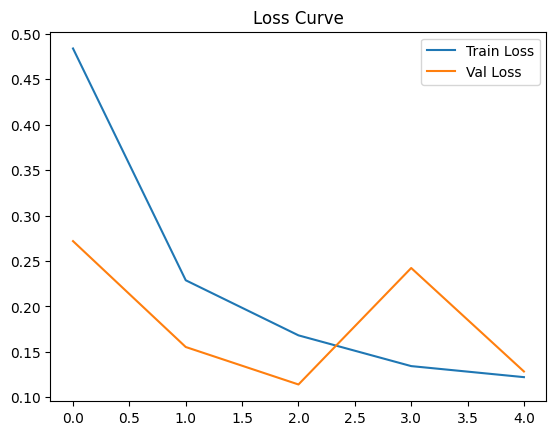

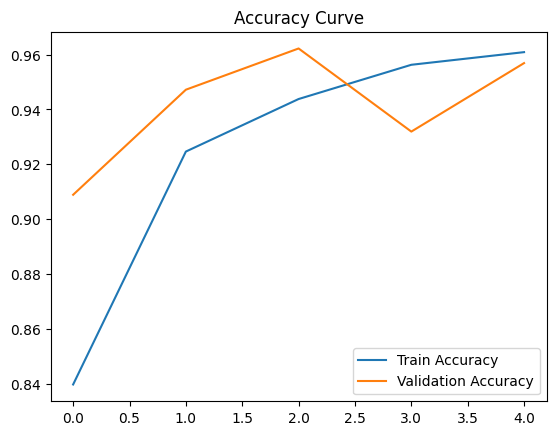

In [42]:
# =========================
# 11. PLOTS
# =========================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()